# 🛡️ SecureMind AI — CICIDS2017 Model Training Pipeline

This notebook continues from `data-preprocessing.ipynb` and uses the cleaned CICIDS2017 dataset.

**Pipeline Overview:**
1. **Load** the cleaned dataset from `data_output/cicids2017_cleaned.csv`
2. **Data Overview** — shape, class distribution, basic stats
3. **Train / Validation / Test Split** — stratified 70% / 15% / 15%
4. **Feature Scaling** — StandardScaler fit on train only
5. **Model Training** — Random Forest, Decision Tree
6. **Evaluation** — accuracy, classification report, confusion matrix
7. **Test Set Evaluation** — best model on held-out test set
8. **Export** — save split data and best model

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load Cleaned Dataset

In [3]:
# Path relative to notebook location (notebooks/CICIDS2017/)
DATA_PATH = os.path.join('..', '..', 'data_output', 'cicids2017_cleaned.csv')

data = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded: {data.shape}")
data.head()

✅ Dataset loaded: (2520751, 48)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Std,Attack Type
0,22,166,1,0,0,0,0.0,0,0,0.000000,...,290,243,0,32,0.000,0.000,0,0,0.000,4
1,60148,83,1,0,0,0,0.0,0,0,0.000000,...,243,290,0,32,0.000,0.000,0,0,0.000,4
2,123,99947,1,48,48,48,48.0,48,48,960.509070,...,-1,-1,0,40,0.000,0.000,0,0,0.000,4
3,123,37017,1,48,48,48,48.0,48,48,2593.403031,...,-1,-1,0,32,0.000,0.000,0,0,0.000,4
4,0,111161336,147,0,0,0,0.0,0,0,0.000000,...,-1,-1,0,0,1753752.625,2123197.578,4822992,95,2657727.996,4


## 3. Data Overview

Dataset shape: (2520751, 48)
Features: 47
Samples:  2,520,751

📊 Class Distribution:
  0 → Bots                                 1,948  (0.08%)
  1 → Brute Force                          9,150  (0.36%)
  2 → DDoS                               128,014  (5.08%)
  3 → DoS                                193,745  (7.69%)
  4 → Normal Traffic                   2,095,057  (83.11%)
  5 → Port Scanning                       90,694  (3.60%)
  6 → Web Attack – Brute Force             1,470  (0.06%)
  7 → Web Attack – SQL Injection              21  (0.00%)
  8 → Web Attack – XSS                       652  (0.03%)


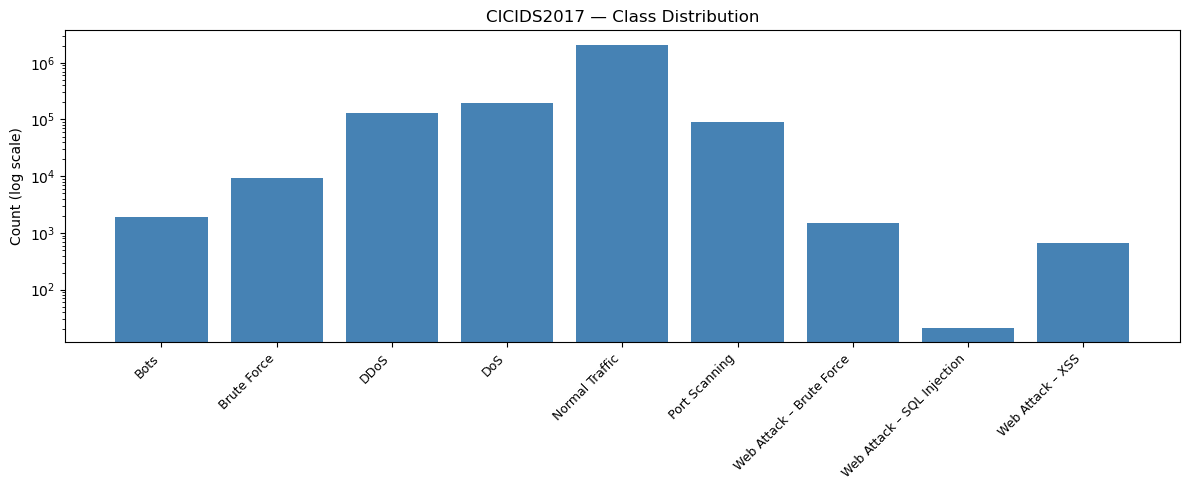

In [4]:
TARGET_COL = 'Attack Type'

# Label mapping (from preprocessing notebook)
LABEL_NAMES = {
    0: 'Bots',
    1: 'Brute Force',
    2: 'DDoS',
    3: 'DoS',
    4: 'Normal Traffic',
    5: 'Port Scanning',
    6: 'Web Attack – Brute Force',
    7: 'Web Attack – SQL Injection',
    8: 'Web Attack – XSS',
}

print(f"Dataset shape: {data.shape}")
print(f"Features: {data.shape[1] - 1}")
print(f"Samples:  {data.shape[0]:,}")
print(f"\n📊 Class Distribution:")
class_dist = data[TARGET_COL].value_counts().sort_index()
for idx, count in class_dist.items():
    pct = count / len(data) * 100
    print(f"  {idx} → {LABEL_NAMES[idx]:30s}  {count:>10,}  ({pct:.2f}%)")

# Visualize class distribution
plt.figure(figsize=(12, 5))
bars = plt.bar(
    [LABEL_NAMES[i] for i in class_dist.index],
    class_dist.values,
    color='steelblue'
)
plt.yscale('log')
plt.ylabel('Count (log scale)')
plt.title('CICIDS2017 — Class Distribution')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split

We use a **stratified** split to preserve class proportions across all sets:
- **Train**: 70%
- **Validation**: 15%
- **Test**: 15%

Two-stage split: first 70/30, then split the 30% into 50/50 (= 15/15).

In [5]:
# Separate features and target
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

# Stage 1: split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Stage 2: split temp into validation (50% of 30% = 15%) and test (50% of 30% = 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

del X_temp, y_temp  # free memory

print(f"✅ Train set:      {X_train.shape[0]:>10,} samples  ({X_train.shape[0]/len(data)*100:.1f}%)")
print(f"✅ Validation set: {X_val.shape[0]:>10,} samples  ({X_val.shape[0]/len(data)*100:.1f}%)")
print(f"✅ Test set:       {X_test.shape[0]:>10,} samples  ({X_test.shape[0]/len(data)*100:.1f}%)")
print(f"\nTotal: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,}")

✅ Train set:       1,764,525 samples  (70.0%)
✅ Validation set:    378,113 samples  (15.0%)
✅ Test set:          378,113 samples  (15.0%)

Total: 2,520,751


In [6]:
# Verify stratification: class proportions should be similar across sets
print("Class proportions across splits (%):\n")
split_df = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True).sort_index() * 100,
    'Validation': y_val.value_counts(normalize=True).sort_index() * 100,
    'Test': y_test.value_counts(normalize=True).sort_index() * 100,
})
split_df.index = [LABEL_NAMES[i] for i in split_df.index]
split_df.round(2)

Class proportions across splits (%):



,Train,Validation,Test
Bots,0.08,0.08,0.08
Brute Force,0.36,0.36,0.36
DDoS,5.08,5.08,5.08
DoS,7.69,7.69,7.69
Normal Traffic,83.11,83.11,83.11
Port Scanning,3.60,3.60,3.60
Web Attack – Brute Force,0.06,0.06,0.06
Web Attack – SQL Injection,0.00,0.00,0.00
Web Attack – XSS,0.03,0.03,0.03


## 5. Feature Scaling

**Important:** The scaler is **fit only on the training set** then used to transform validation and test sets. This prevents data leakage.

In [7]:
scaler = StandardScaler()

# Fit on train, transform all sets
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"✅ Scaling complete (fit on train only)")
print(f"   Train mean ≈ {X_train_scaled.mean().mean():.6f}, std ≈ {X_train_scaled.std().mean():.6f}")
print(f"   Val   mean ≈ {X_val_scaled.mean().mean():.6f}, std ≈ {X_val_scaled.std().mean():.6f}")
print(f"   Test  mean ≈ {X_test_scaled.mean().mean():.6f}, std ≈ {X_test_scaled.std().mean():.6f}")

✅ Scaling complete (fit on train only)
   Train mean ≈ -0.000000, std ≈ 1.000000
   Val   mean ≈ -0.000204, std ≈ 1.162986
   Test  mean ≈ 0.000074, std ≈ 1.013427


## 6. Model Training

We train two classifiers and evaluate each on the **validation set**:
1. **Decision Tree** — fast, interpretable baseline
2. **Random Forest** — ensemble, typically strong on tabular data


In [8]:
# Helper function for training and evaluating a model
def train_and_evaluate(name, model, X_tr, y_tr, X_v, y_v, label_names):
    """Train a model, evaluate on validation set, return results dict."""
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")

    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    print(f"  ⏱️  Training time: {train_time:.2f}s")

    # Predict on validation
    start = time.time()
    y_pred = model.predict(X_v)
    pred_time = time.time() - start

    acc = accuracy_score(y_v, y_pred)
    print(f"  ✅ Validation Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  ⏱️  Prediction time:  {pred_time:.2f}s")

    # Classification report
    target_names = [label_names[i] for i in sorted(label_names.keys())]
    report = classification_report(
        y_v, y_pred,
        target_names=target_names,
        zero_division=0
    )
    print(f"\n{report}")

    return {
        'name': name,
        'model': model,
        'accuracy': acc,
        'train_time': train_time,
        'pred_time': pred_time,
        'y_pred': y_pred,
    }

print("✅ Helper function defined")

✅ Helper function defined


### 6.1 Decision Tree

In [9]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=20)

dt_results = train_and_evaluate(
    'Decision Tree', dt_model,
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    LABEL_NAMES
)


  Training: Decision Tree
  ⏱️  Training time: 151.31s
  ✅ Validation Accuracy: 0.9983  (99.83%)
  ⏱️  Prediction time:  0.11s

                            precision    recall  f1-score   support

                      Bots       0.83      0.80      0.81       292
               Brute Force       1.00      1.00      1.00      1372
                      DDoS       1.00      1.00      1.00     19202
                       DoS       1.00      1.00      1.00     29062
            Normal Traffic       1.00      1.00      1.00    314259
             Port Scanning       0.99      0.99      0.99     13604
  Web Attack – Brute Force       0.70      0.77      0.73       221
Web Attack – SQL Injection       1.00      0.33      0.50         3
          Web Attack – XSS       0.35      0.26      0.29        98

                  accuracy                           1.00    378113
                 macro avg       0.87      0.79      0.81    378113
              weighted avg       1.00      1.00      

### 6.2 Random Forest

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_results = train_and_evaluate(
    'Random Forest', rf_model,
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    LABEL_NAMES
)


  Training: Random Forest
  ⏱️  Training time: 663.97s
  ✅ Validation Accuracy: 0.9985  (99.85%)
  ⏱️  Prediction time:  4.43s

                            precision    recall  f1-score   support

                      Bots       0.94      0.44      0.60       292
               Brute Force       1.00      1.00      1.00      1372
                      DDoS       1.00      1.00      1.00     19202
                       DoS       1.00      1.00      1.00     29062
            Normal Traffic       1.00      1.00      1.00    314259
             Port Scanning       0.99      1.00      0.99     13604
  Web Attack – Brute Force       0.71      0.99      0.83       221
Web Attack – SQL Injection       0.00      0.00      0.00         3
          Web Attack – XSS       0.86      0.06      0.11        98

                  accuracy                           1.00    378113
                 macro avg       0.83      0.72      0.73    378113
              weighted avg       1.00      1.00      

## 7. Model Comparison

In [11]:
# Compare all models
all_results = [dt_results, rf_results]

comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Val Accuracy': f"{r['accuracy']*100:.2f}%",
        'Train Time (s)': f"{r['train_time']:.2f}",
        'Pred Time (s)': f"{r['pred_time']:.2f}",
    }
    for r in all_results
])

print("\n📊 Model Comparison (Validation Set):")
print(comparison_df.to_string(index=False))

# Find the best model
best = max(all_results, key=lambda x: x['accuracy'])
print(f"\n🏆 Best Model: {best['name']} with {best['accuracy']*100:.2f}% accuracy")


📊 Model Comparison (Validation Set):
        Model Val Accuracy Train Time (s) Pred Time (s)
Decision Tree       99.83%         151.31          0.11
Random Forest       99.85%         663.97          4.43

🏆 Best Model: Random Forest with 99.85% accuracy


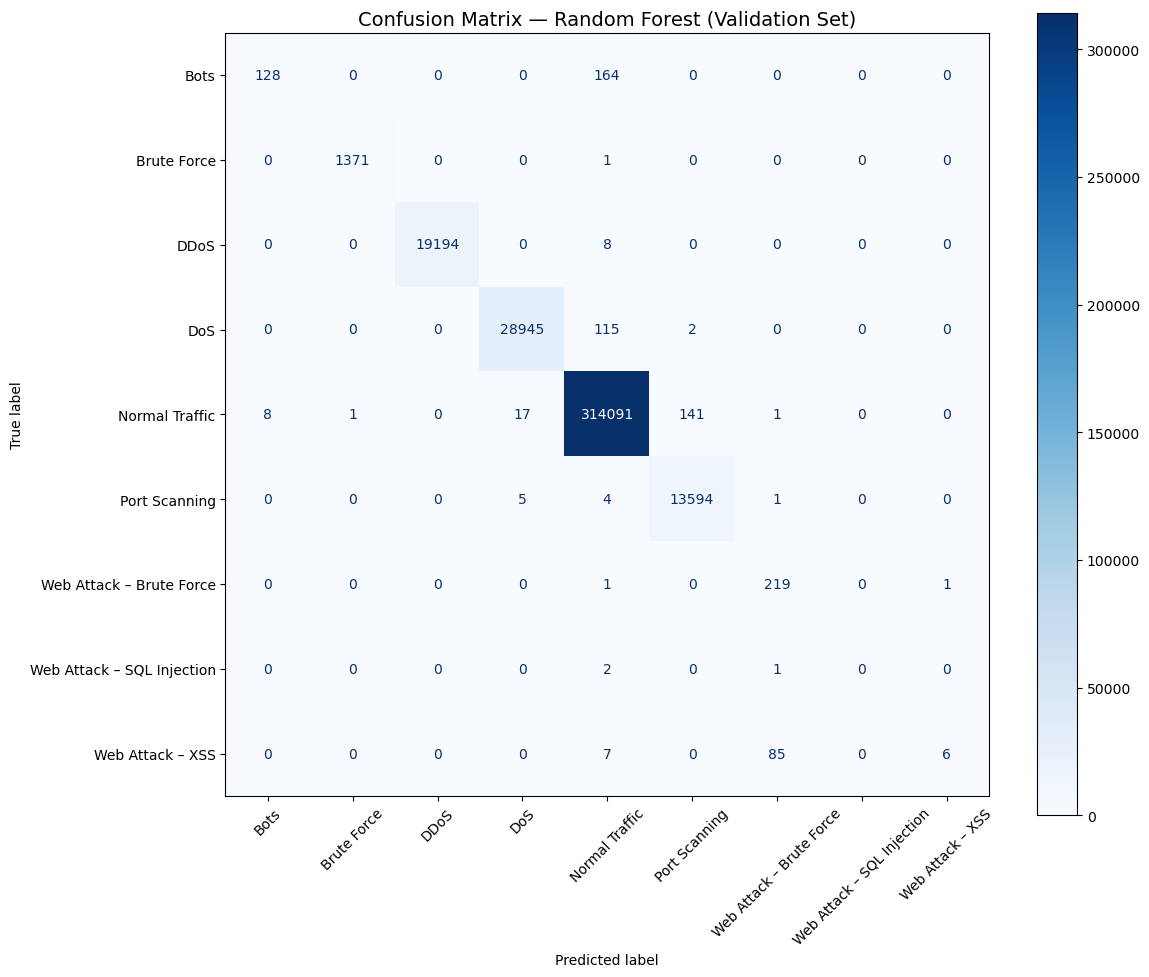

In [12]:
# Confusion Matrix for the best model on validation set
target_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())]

fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_val, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title(f"Confusion Matrix — {best['name']} (Validation Set)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Test Set Evaluation

Evaluate the **best model** on the held-out **test set** for final, unbiased performance estimation.


  Final Evaluation: Random Forest on TEST SET

  🎯 Test Accuracy: 0.9986  (99.86%)

                            precision    recall  f1-score   support

                      Bots       0.92      0.46      0.61       292
               Brute Force       1.00      1.00      1.00      1373
                      DDoS       1.00      1.00      1.00     19202
                       DoS       1.00      1.00      1.00     29062
            Normal Traffic       1.00      1.00      1.00    314259
             Port Scanning       0.99      1.00      0.99     13604
  Web Attack – Brute Force       0.71      0.96      0.82       220
Web Attack – SQL Injection       0.00      0.00      0.00         3
          Web Attack – XSS       0.82      0.09      0.17        98

                  accuracy                           1.00    378113
                 macro avg       0.83      0.72      0.73    378113
              weighted avg       1.00      1.00      1.00    378113



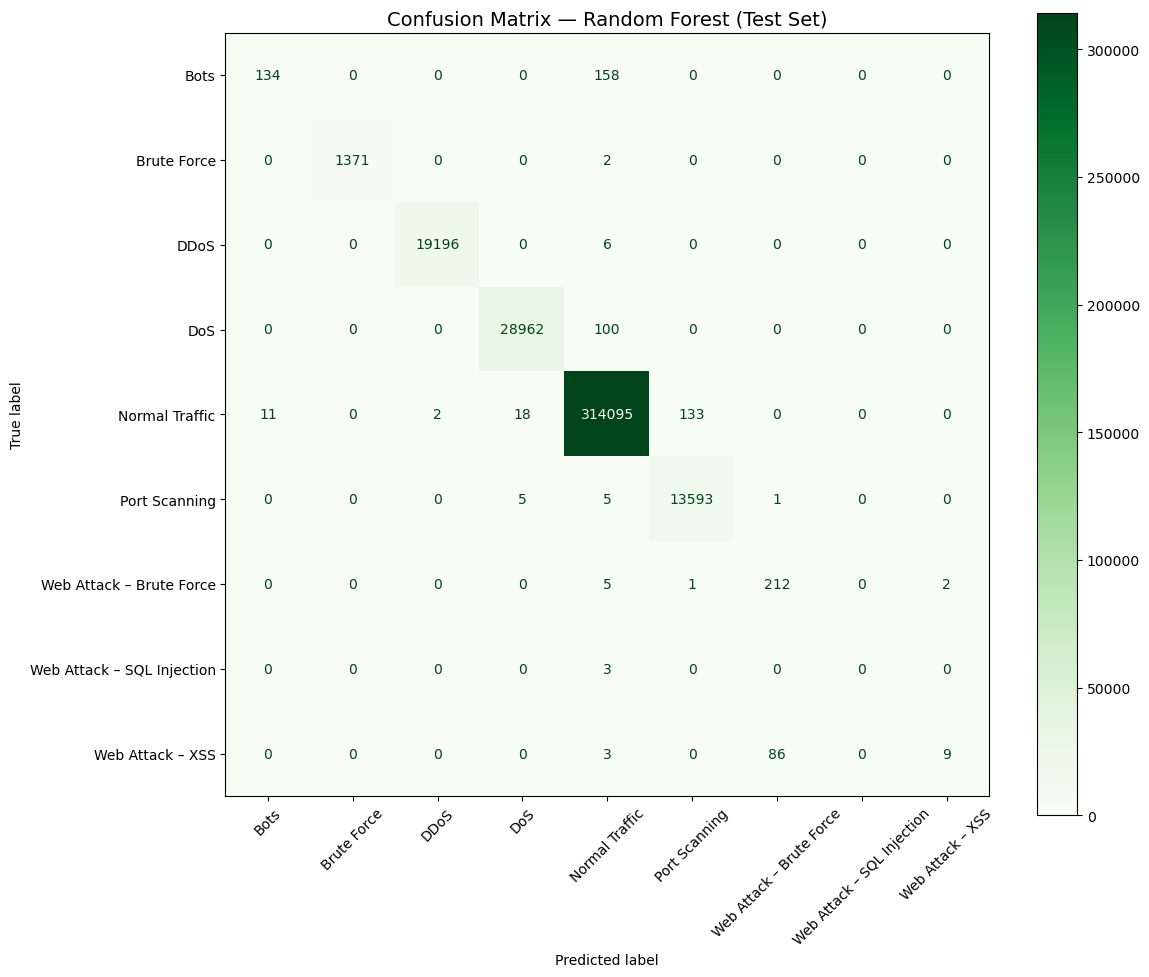

In [13]:
print(f"\n{'='*60}")
print(f"  Final Evaluation: {best['name']} on TEST SET")
print(f"{'='*60}")

y_test_pred = best['model'].predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n  🎯 Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"\n{classification_report(y_test, y_test_pred, target_names=target_names, zero_division=0)}")

# Confusion Matrix for test set
fig, ax = plt.subplots(figsize=(12, 10))
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=target_names)
disp_test.plot(ax=ax, cmap='Greens', xticks_rotation=45, values_format='d')
ax.set_title(f"Confusion Matrix — {best['name']} (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Export Split Datasets & Model

Save:
- Train / Validation / Test sets as CSV files
- The best trained model using `joblib`
- The fitted scaler using `joblib`

In [14]:
OUTPUT_DIR = os.path.join('..', '..', 'data_output')
MODEL_DIR = os.path.join('..', '..', 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Save split datasets ---
# Train
train_df = X_train.copy()
train_df[TARGET_COL] = y_train
train_path = os.path.join(OUTPUT_DIR, 'cicids2017_train.csv')
train_df.to_csv(train_path, index=False)
print(f"✅ Train set saved: {train_path}  ({train_df.shape[0]:,} rows)")

# Validation
val_df = X_val.copy()
val_df[TARGET_COL] = y_val
val_path = os.path.join(OUTPUT_DIR, 'cicids2017_val.csv')
val_df.to_csv(val_path, index=False)
print(f"✅ Validation set saved: {val_path}  ({val_df.shape[0]:,} rows)")

# Test
test_df = X_test.copy()
test_df[TARGET_COL] = y_test
test_path = os.path.join(OUTPUT_DIR, 'cicids2017_test.csv')
test_df.to_csv(test_path, index=False)
print(f"✅ Test set saved: {test_path}  ({test_df.shape[0]:,} rows)")

# --- Save the best model ---
model_name = best['name'].lower().replace(' ', '_')
model_path = os.path.join(MODEL_DIR, f'cicids2017_best_model_{model_name}.joblib')
joblib.dump(best['model'], model_path)
print(f"\n🏆 Best model saved: {model_path}")

# --- Save the scaler ---
scaler_path = os.path.join(MODEL_DIR, 'cicids2017_scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"📐 Scaler saved: {scaler_path}")

# --- Save label mapping ---
label_map_path = os.path.join(MODEL_DIR, 'cicids2017_label_map.joblib')
joblib.dump(LABEL_NAMES, label_map_path)
print(f"🏷️  Label map saved: {label_map_path}")

print(f"\n✅ All exports complete!")

✅ Train set saved: ../../data_output/cicids2017_train.csv  (1,764,525 rows)
✅ Validation set saved: ../../data_output/cicids2017_val.csv  (378,113 rows)
✅ Test set saved: ../../data_output/cicids2017_test.csv  (378,113 rows)

🏆 Best model saved: ../../models/cicids2017_best_model_random_forest.joblib
📐 Scaler saved: ../../models/cicids2017_scaler.joblib
🏷️  Label map saved: ../../models/cicids2017_label_map.joblib

✅ All exports complete!


In [15]:
# Quick verification: reload model and test
print("\n🔍 Verification: reloading saved model...")
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# Predict on first 5 test samples
sample = X_test.head(5)
sample_scaled = loaded_scaler.transform(sample)
preds = loaded_model.predict(sample_scaled)

loaded_labels = joblib.load(label_map_path)
print("Predictions on 5 test samples:")
for i, (pred, true) in enumerate(zip(preds, y_test.head(5).values)):
    status = '✅' if pred == true else '❌'
    print(f"  {status} Predicted: {loaded_labels[pred]:30s} | Actual: {loaded_labels[true]}")

print("\n✅ Model export verified successfully!")


🔍 Verification: reloading saved model...
Predictions on 5 test samples:
  ✅ Predicted: Normal Traffic                 | Actual: Normal Traffic
  ✅ Predicted: Normal Traffic                 | Actual: Normal Traffic
  ✅ Predicted: Normal Traffic                 | Actual: Normal Traffic
  ✅ Predicted: Normal Traffic                 | Actual: Normal Traffic
  ✅ Predicted: Normal Traffic                 | Actual: Normal Traffic

✅ Model export verified successfully!
